<a href="https://colab.research.google.com/github/raz0208/PedestrianDetection/blob/main/Model_Implementation%20/Pedestrian-Detection-(Object-Detection)-MMH.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**This stage imports the necessary libraries: zipfile for handling zip archives, os for interacting with the operating system and file paths, and PIL (Pillow) for image processing tasks like opening and converting image files**


In [ ]:
import zipfile
import os
from PIL import Image

This stage involves converting all .tif images in the source directory (and its subdirectories) to .jpg format and saving them in a specified destination directory.









In [ ]:
def convert_and_copy_images(src_dir, dest_dir):
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    for root, dirs, files in os.walk(src_dir):
        for file in files:
            if file.lower().endswith('.tif'):
                file_path = os.path.join(root, file)
                with Image.open(file_path) as img:
                    # Change the file extension to .jpg
                    new_file_name = os.path.splitext(file)[0] + '.jpg'
                    new_file_path = os.path.join(dest_dir, new_file_name)

                    img.convert("RGB").save(new_file_path, "JPEG")
source_folder = '/kaggle/input/city-persone/gtFinePanopticParts_trainval/gtFinePanopticParts/train'
destination_folder = '/kaggle/working/gtFinePanopticParts/train/images'
convert_and_copy_images(source_folder, destination_folder)

In [ ]:
def convert_and_copy_images(src_dir, dest_dir):
    if not os.path.exists(dest_dir):
        os.makedirs(dest_dir)

    for root, dirs, files in os.walk(src_dir):
        for file in files:
            if file.lower().endswith('.tif'):
                # Full path to the .tif image
                file_path = os.path.join(root, file)

                with Image.open(file_path) as img:
                    # Change the file extension to .jpg
                    new_file_name = os.path.splitext(file)[0] + '.jpg'
                    new_file_path = os.path.join(dest_dir, new_file_name)

                    img.convert("RGB").save(new_file_path, "JPEG")
# Example usage
source_folder = '/kaggle/input/city-persone/gtFinePanopticParts_trainval/gtFinePanopticParts/val'
destination_folder = '/kaggle/working/gtFinePanopticParts/val/images'
convert_and_copy_images(source_folder, destination_folder)

****This stage processes all JSON annotation files in the source directory, converting each annotation into the YOLO format. It extracts the bounding box information and class labels, maps them to YOLO class IDs, and normalizes the bounding box coordinates relative to the image size. The resulting YOLO-compatible data is saved as .txt files in the specified output directory.****









In [ ]:
import json
import os

# Mapping of class labels to YOLOv5 class IDs
class_mapping = {
    "pedestrian": 0,
    "rider": 1,
    "sitting person": 2,
    "person group": 3,
}
def convert_bbox_to_yolo(bbox, img_width, img_height):
    """
    Convert bounding box coordinates from [x_min, y_min, width, height]
    to YOLO format (x_center, y_center, width, height) normalized to image size.
    """
    x_min, y_min, width, height = bbox
    x_center = (x_min + width / 2) / img_width
    y_center = (y_min + height / 2) / img_height
    w = width / img_width
    h = height / img_height
    return x_center, y_center, w, h

def convert_json_to_yolo_txt(json_path, output_dir):
    """
    Convert the JSON annotation to YOLO text file format.
    """
    with open(json_path, 'r') as file:
        data = json.load(file)

    img_width = data["imgWidth"]
    img_height = data["imgHeight"]

    # Prepare the output filename based on the input JSON file
    txt_filename = os.path.splitext(os.path.basename(json_path))[0] + ".txt"
    txt_path = os.path.join(output_dir, txt_filename)

    with open(txt_path, 'w') as txt_file:
        for obj in data["objects"]:
            label = obj["label"]
            if label not in class_mapping:
                continue  # Skip labels that aren't in the class_mapping

            class_id = class_mapping[label]
            bbox = obj["bbox"]

            # Convert bounding box to YOLO format
            x_center, y_center, w, h = convert_bbox_to_yolo(bbox, img_width, img_height)

            # Write to the YOLO formatted .txt file
            txt_file.write(f"{class_id} {x_center} {y_center} {w} {h}\n")

def process_json_files_in_dir(src_dir, output_dir):
    """
    Walk through each folder and subfolder in src_dir, and process all JSON files.
    Convert them to YOLO text format.
    """
    for root, dirs, files in os.walk(src_dir):
        for file in files:
            if file.endswith('.json'):
                json_path = os.path.join(root, file)
                convert_json_to_yolo_txt(json_path, output_dir)

# Define input and output directories
src_dir = '/kaggle/input/city-persone/gtBbox_cityPersons_trainval/gtBboxCityPersons/val'
output_dir = '/kaggle/working/gtFinePanopticParts/val/labels'

# Make sure output directory exists
os.makedirs(output_dir, exist_ok=True)

# Process all JSON files in the source directory and its subdirectories
process_json_files_in_dir(src_dir, output_dir)

In [ ]:
import json
import os
import shutil

# Mapping of class labels to YOLOv5 class IDs
# Mapping of class labels to YOLOv5 class IDs
class_mapping = {
    "pedestrian": 0,
    "rider": 1,
    "sitting person": 2,
    "person group": 3,
}
def convert_bbox_to_yolo(bbox, img_width, img_height):
    """
    Convert bounding box coordinates from [x_min, y_min, width, height]
    to YOLO format (x_center, y_center, width, height) normalized to image size.
    """
    x_min, y_min, width, height = bbox
    x_center = (x_min + width / 2) / img_width
    y_center = (y_min + height / 2) / img_height
    w = width / img_width
    h = height / img_height
    return x_center, y_center, w, h

def convert_json_to_yolo_txt(json_path, output_dir):
    """
    Convert the JSON annotation to YOLO text file format.
    """
    with open(json_path, 'r') as file:
        data = json.load(file)

    img_width = data["imgWidth"]
    img_height = data["imgHeight"]

    # Prepare the output filename based on the input JSON file
    txt_filename = os.path.splitext(os.path.basename(json_path))[0] + ".txt"
    txt_path = os.path.join(output_dir, txt_filename)

    with open(txt_path, 'w') as txt_file:
        for obj in data["objects"]:
            label = obj["label"]
            if label not in class_mapping:
                continue  # Skip labels that aren't in the class_mapping

            class_id = class_mapping[label]
            bbox = obj["bbox"]

            # Convert bounding box to YOLO format
            x_center, y_center, w, h = convert_bbox_to_yolo(bbox, img_width, img_height)

            # Write to the YOLO formatted .txt file
            txt_file.write(f"{class_id} {x_center} {y_center} {w} {h}\n")

def process_json_files_in_dir(src_dir, output_dir):
    """
    Walk through each folder and subfolder in src_dir, and process all JSON files.
    Convert them to YOLO text format and copy the original JSON files to the output directory.
    """
    for root, dirs, files in os.walk(src_dir):
        for file in files:
            if file.endswith('.json'):
                json_path = os.path.join(root, file)

                # Convert JSON to YOLO text format
                convert_json_to_yolo_txt(json_path, output_dir)

                # Copy the original JSON file to the output directory
                shutil.copy2(json_path, output_dir)

src_dir = '/kaggle/input/city-persone/gtBbox_cityPersons_trainval/gtBboxCityPersons/train'
output_dir = '/kaggle/working/gtFinePanopticParts/train/labels'

os.makedirs(output_dir, exist_ok=True)

process_json_files_in_dir(src_dir, output_dir)

****This stage renames all .txt files in the specified directories by replacing the substring "BboxCityPersons" with "FinePanopticParts" in their filenames. It ensures that the files are renamed correctly by iterating through the directory and applying the change to all matching files.****









In [ ]:
import os

def rename_files_in_dir(output_dir):
    """
    Rename all .txt files in the output_dir by replacing 'BboxCityPersons' with 'FinePanopticParts'.
    """
    # Loop through all files in the directory
    for file_name in os.listdir(output_dir):
        # Check if the file is a .txt file
        if file_name.endswith('.txt'):
            # Replace 'BboxCityPersons' with 'FinePanopticParts' in the file name
            new_name = file_name.replace('BboxCityPersons', 'FinePanopticParts')

            # Get the full path of the old and new file names
            old_file_path = os.path.join(output_dir, file_name)
            new_file_path = os.path.join(output_dir, new_name)

            # Rename the file
            os.rename(old_file_path, new_file_path)

output_dir = '/kaggle/working/gtFinePanopticParts/val/labels'  # Replace with the actual path to your folder
output_dir1 = '/kaggle/working/gtFinePanopticParts/train/labels'  # Replace with the actual path to your folder

rename_files_in_dir(output_dir)
rename_files_in_dir(output_dir1)

This stage compares the filenames of images and their corresponding label files in the validation directories to ensure they match (ignoring file extensions). It identifies and prints any unmatched image or label files, helping to verify that every image has a corresponding label file. If no unmatched files are found, it confirms that all validation images and labels match.
also removes all .json files from the specified directory. It iterates through the files in the directory, identifies those with a .json extension, and deletes them. Any errors during the deletion process are caught and printed for troubleshooting.









In [ ]:
import os

def remove_json_files(directory):
    # List all files in the directory
    files_in_directory = os.listdir(directory)

    # Iterate through the list of files
    for file in files_in_directory:
        # Check if the file ends with '.json'
        if file.endswith('.json'):
            file_path = os.path.join(directory, file)
            try:
                os.remove(file_path)  # Remove the file
            except Exception as e:
                print(f"Error removing {file_path}: {e}")

# Example usage:
folder_path = "/kaggle/working/gtFinePanopticParts/train/labels"  # Replace with the folder where you want to remove the .json files
remove_json_files(folder_path)
import os

# Directories for images and labels
val_image_dir = '/kaggle/working/gtFinePanopticParts/train/images'
val_label_dir = '/kaggle/working/gtFinePanopticParts/train/labels'

# Get the list of image files and label files
val_images = set(os.listdir(val_image_dir))
val_labels = set(os.listdir(val_label_dir))

# Ensure both lists contain the files with the same base name (ignoring file extensions)
image_base_names = {os.path.splitext(f)[0] for f in val_images if f.endswith('.jpg')}
label_base_names = {os.path.splitext(f)[0] for f in val_labels if f.endswith('.txt')}

# Check if there are any unmatched files
unmatched_images = image_base_names - label_base_names
unmatched_labels = label_base_names - image_base_names

# Print the results
print(f"Number of validation images: {len(val_images)}")
print(f"Number of validation label files: {len(val_labels)}")
print(f"Unmatched image files: {len(unmatched_images)}")
print(f"Unmatched label files: {len(unmatched_labels)}")
print()

# If all is correct, the unmatched sets should be empty
if not unmatched_images and not unmatched_labels:
    print("All validation images and labels match!")
else:
    print("Some validation images and labels do not match.")
    print(f"Unmatched images: {unmatched_images}")
    print(f"Unmatched labels: {unmatched_labels}")
# Define the directories

Number of validation images: 2975
Number of validation label files: 2975
Unmatched image files: 0
Unmatched label files: 0

All validation images and labels match!


This stage removes all .json files from the specified directory. It iterates through the files in the directory, identifies those with a .json extension, and deletes them. Any errors during the deletion process are caught and printed for troubleshooting.









This stage processes each label file in the specified directory to identify  objects based on their bounding box dimensions. It calculates the pixel size of each object by converting normalized width and height to pixel values. If any object's width or height is smaller than a defined threshold , it counts the object as small. The total number of small objects and the count for each class are then printed for further analysis.









In [ ]:
import os
from collections import defaultdict

# Define paths and image size
labels_path = "/kaggle/working/gtFinePanopticParts/train/labels"  # Path to your labels folder
image_width = 640  # Width of your images
image_height = 640  # Height of your images
pixel_threshold = 100000000  # Minimum pixel size

# Initialize counters
total_small_objects = 0
class_small_counts = defaultdict(int)  # Stores counts for each class

# Process each label file
for label_file in os.listdir(labels_path):
    if label_file.endswith(".txt"):
        file_path = os.path.join(labels_path, label_file)
        with open(file_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls, x_center, y_center, width, height = map(float, parts)
                # Convert normalized width and height to pixel dimensions
                bbox_width_pixels = width * image_width
                bbox_height_pixels = height * image_height

                # Check if either dimension is smaller than the threshold
                if bbox_width_pixels < pixel_threshold or bbox_height_pixels < pixel_threshold:
                    total_small_objects += 1
                    class_small_counts[int(cls)] += 1  # Increment count for the class

# Output the results
print(f"Total number of  objects : {total_small_objects}")
print("Per-class  object counts:")
for cls, count in class_small_counts.items():
    print(f"Class {cls}: {count}  objects")

Total number of  objects : 20585
Per-class  object counts:
Class 0: 16526  objects
Class 1: 1680  objects
Class 2: 1032  objects
Class 3: 1347  objects


In [ ]:
import os
from collections import defaultdict

# Define paths and image size
labels_path = "/kaggle/working/gtFinePanopticParts/train/labels"  # Path to your labels folder
image_width = 640  # Width of your images
image_height = 640  # Height of your images
pixel_threshold = 1000000  # Minimum pixel size

# Initialize counters
total_small_objects = 0
class_small_counts = defaultdict(int)  # Stores counts for each class

# Process each label file
for label_file in os.listdir(labels_path):
    if label_file.endswith(".txt"):
        file_path = os.path.join(labels_path, label_file)
        with open(file_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls, x_center, y_center, width, height = map(float, parts)
                # Convert normalized width and height to pixel dimensions
                bbox_width_pixels = width * image_width
                bbox_height_pixels = height * image_height

                # Check if either dimension is smaller than the threshold
                if bbox_width_pixels < pixel_threshold or bbox_height_pixels < pixel_threshold:
                    total_small_objects += 1
                    class_small_counts[int(cls)] += 1  # Increment count for the class

# Output the results
print(f"Total number of small objects (<3 pixels): {total_small_objects}")
print("Per-class small object counts:")
for cls, count in class_small_counts.items():
    print(f"Class {cls}: {count} small objects")

Total number of small objects (<3 pixels): 20585
Per-class small object counts:
Class 0: 16526 small objects
Class 1: 1680 small objects
Class 2: 1032 small objects
Class 3: 1347 small objects


This stage filters label files based on specific criteria: it only keeps files that contain classes 2 or 3 (while excluding class 0), and it ensures that the files are not solely composed of class 1 objects. It also checks for bounding boxes that meet a minimum area threshold and filters out small ones. The resulting filtered label files are collected, and the class distribution across the files is updated and displayed.









In [ ]:
import os
from collections import defaultdict

# Define paths
labels_path = "/kaggle/working/gtFinePanopticParts/train/labels"

# Define the minimum area threshold for valid bounding boxes
MIN_AREA_THRESHOLD = 0  # Adjust as needed

# List to store filtered label files
filtered_labels = []

# Dictionary to store class distribution
class_distribution = defaultdict(int)

# Filter label files
for label_file in os.listdir(labels_path):
    if label_file.endswith(".txt"):
        file_path = os.path.join(labels_path, label_file)
        contains_valid_class = False  # Flag for class 2 or 3
        contains_class_0 = False  # Flag for class 0
        contains_class_1_only = True  # Assume true until another class is found
        class_counts = defaultdict(int)  # Track class counts in this file

        with open(file_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls = int(parts[0])
                x, y, width, height = map(float, parts[1:5])  # Extract bounding box details

                # Compute area
                area = width * height  # Area in YOLO format (normalized)

                # Count occurrences of each class
                class_counts[cls] += 1

                # If class 0 is present, discard this image
                if cls == 0:
                    contains_class_0 = True
                    break  # Stop processing further; we don't want this image

                # If the bounding box area is too small, ignore it
                if area < MIN_AREA_THRESHOLD:
                    continue

                # If we find class 2 or 3, the file does not contain only class 1
                if cls in [2, 3]:
                    contains_valid_class = True
                    contains_class_1_only = False  # Since another class is present

                # If class is not 1, it's not a "class 1 only" file
                if cls != 1:
                    contains_class_1_only = False

        # Keep only files that:
        # - Contain class 2 or 3
        # - Do not contain class 0
        # - Are not "class 1 only" files
        if contains_valid_class and not contains_class_0 and not contains_class_1_only:
            filtered_labels.append(label_file)

            # Update global class distribution
            for cls, count in class_counts.items():
                class_distribution[cls] += count

# Output the names of filtered label files
print(f"Filtered label files ({len(filtered_labels)}):")
for label in filtered_labels:
    print(label)

# Output class distribution
print("\nClass Distribution after filtering:")
for cls, count in sorted(class_distribution.items()):
    print(f"Class {cls}: {count} instances")

Filtered label files (36):
zurich_000031_000019_gtFinePanopticParts.txt
krefeld_000000_012505_gtFinePanopticParts.txt
strasbourg_000000_035942_gtFinePanopticParts.txt
strasbourg_000001_014629_gtFinePanopticParts.txt
aachen_000166_000019_gtFinePanopticParts.txt
dusseldorf_000094_000019_gtFinePanopticParts.txt
zurich_000016_000019_gtFinePanopticParts.txt
cologne_000117_000019_gtFinePanopticParts.txt
hanover_000000_019116_gtFinePanopticParts.txt
erfurt_000042_000019_gtFinePanopticParts.txt
cologne_000118_000019_gtFinePanopticParts.txt
strasbourg_000001_015974_gtFinePanopticParts.txt
bremen_000290_000019_gtFinePanopticParts.txt
strasbourg_000001_031582_gtFinePanopticParts.txt
cologne_000070_000019_gtFinePanopticParts.txt
bremen_000191_000019_gtFinePanopticParts.txt
strasbourg_000001_013767_gtFinePanopticParts.txt
hamburg_000000_098061_gtFinePanopticParts.txt
monchengladbach_000000_009615_gtFinePanopticParts.txt
dusseldorf_000069_000019_gtFinePanopticParts.txt
monchengladbach_000000_009930_

This stage filters label files based on the pattern "CITYNAME_6NUM_6NUM" (where CITYNAME is a sequence of letters and 6NUM represents a six-digit number) and copies the matching files to a new destination folder. It uses a regular expression to identify valid filenames, checks them against the filtered set, and copies the matching files from the source directory to the destination. The total number of copied files is then reported.









In [ ]:
import os
import shutil
import re

# Source directory containing the labels
labels_path = '/kaggle/working/gtFinePanopticParts/train/labels'

# Destination folder for filtered labels
destination_labels_folder = "/kaggle/working/filtered/labels"
os.makedirs(destination_labels_folder, exist_ok=True)

# List of filtered filenames or patterns

# Regex to match "CITYNAME_6NUM_6NUM"
city_pattern_regex = re.compile(r"^[a-zA-Z]+_\d{6}_\d{6}")

# Extract valid "CITYNAME_6NUM_6NUM" patterns from `filtered_labels`
filtered_patterns = set()
for label in filtered_labels:
    match = city_pattern_regex.match(label)
    if match:
        city_pattern = '_'.join(label.split('_')[:3])  # Extract city and number pattern
        filtered_patterns.add(city_pattern)

# Validate the patterns being searched for

# Initialize a counter for the number of files copied
files_copied = 0

# Walk through each folder and subfolder in labels_path
for root, _, files in os.walk(labels_path):
    for file in files:
        # Check if the filename matches the "CITYNAME_6NUM_6NUM" pattern
        match = city_pattern_regex.match(file)
        if match:
            city_pattern = '_'.join(file.split('_')[:3])  # Extract city and number pattern
            if city_pattern in filtered_patterns:  # Check if it matches the filtered patterns
                src_label_path = os.path.join(root, file)
                dest_label_path = os.path.join(destination_labels_folder, file)
                shutil.copy(src_label_path, dest_label_path)
                files_copied += 1

print(f"Copied {files_copied} files with matching patterns to {destination_labels_folder}")

Copied 36 files with matching patterns to /kaggle/working/filtered/labels


This stage renames the files in the destination folder by replacing the substring "BboxCityPersons" with "FinePanopticParts" in the filenames. It iterates through each file in the destination folder, constructs the new filename, and renames the file accordingly.









In [ ]:
# Directory where files are copied
destination_labels_folder = "/kaggle/working/filtered/labels"

# Rename the copied files in the destination folder
for file_name in os.listdir(destination_labels_folder):
    old_path = os.path.join(destination_labels_folder, file_name)

    # New name: replace 'BboxCityPersons' with 'FinePanopticParts'
    new_name = file_name.replace('BboxCityPersons', 'FinePanopticParts')
    new_path = os.path.join(destination_labels_folder, new_name)

    # Rename the file
    os.rename(old_path, new_path)

This stage counts the total number of files in a specified folder and its subdirectories. It iterates through all the directories within the folder, adds up the files in each directory, and then prints the total file count.









In [ ]:
import os

def count_files_in_folder(folder_path):
    file_count = 0

    # Walk through all subdirectories and files in the given folder
    for root, dirs, files in os.walk(folder_path):
        file_count += len(files)  # Add the number of files in this directory

    return file_count

# Specify the folder path you want to count files in
folder_path = "/kaggle/working/filtered/augmented2/images"  # Example path

# Count the files
total_files = count_files_in_folder(folder_path)

# Print the total file count
print(f"Total files in folder {folder_path}: {total_files}")

Total files in folder /kaggle/working/filtered/augmented2/images: 0


This stage copies images corresponding to the filtered label files based on a specific filename pattern ("CITYNAME_6NUM_6NUM"). It uses a regular expression to match and extract the pattern from the label filenames and searches for matching images in the images directory. When a corresponding image is found, it is copied to a new destination folder. The total number of copied images is tracked and displayed.









In [ ]:
import os
import shutil
import re

# Define paths for images and the destination folder
images_path = "/kaggle/working/gtFinePanopticParts/train/images"
destination_images_folder = "/kaggle/working/filtered/images"
os.makedirs(destination_images_folder, exist_ok=True)

# List of filtered label filenames


# Regex to match "CITYNAME_6NUM_6NUM"
city_pattern_regex = re.compile(r"^[a-zA-Z]+_\d{6}_\d{6}")

# Initialize a counter for copied images
copied_images_count = 0

# Extract valid "CITYNAME_6NUM_6NUM" patterns from `filtered_labels` using regex
filtered_patterns = set()
for label in filtered_labels:
    # Match the pattern against the label filename
    match = city_pattern_regex.match(label)
    if match:
        # Extract the "CITYNAME_6NUM_6NUM" pattern from the label
        city_pattern = '_'.join(label.split('_')[:3])  # cityname_6digit_6digit
        filtered_patterns.add(city_pattern)

# Validate the patterns being searched for

# Copy corresponding images based on the regex city pattern
for label_file in filtered_labels:
    # Get the base name of the file (without extension)
    base_name = os.path.splitext(label_file)[0]

    # Match the pattern against the label's base name using regex
    label_match = city_pattern_regex.match(base_name)
    if label_match:
        # Extract the city pattern (e.g., 'strasbourg_000000_009930') from the label file
        label_city_pattern = '_'.join(base_name.split('_')[:3])

        # If the pattern matches a filtered one, search for corresponding images
        if label_city_pattern in filtered_patterns:
            found = False
            for image_file in os.listdir(images_path):
                # Match image file names using regex to check if they match the base name
                if city_pattern_regex.match(image_file):
                    image_base_name = os.path.splitext(image_file)[0]
                    # If the image starts with the same city pattern, copy it
                    if image_base_name.startswith(label_city_pattern):
                        src_image_path = os.path.join(images_path, image_file)
                        dest_image_path = os.path.join(destination_images_folder, image_file)
                        shutil.copy(src_image_path, dest_image_path)
                        copied_images_count += 1  # Increment the counter
                        found = True
                        break

            if not found:
                print(f"Warning: No image found for label {label_file}")

# Output the total number of copied images
print(f"Total images copied: {copied_images_count}")
print(f"Copied images are saved in: {destination_images_folder}")

Total images copied: 36
Copied images are saved in: /kaggle/working/filtered/images


In [ ]:
import os

def remove_json_files(directory):
    # List all files in the directory
    files_in_directory = os.listdir(directory)

    # Iterate through the list of files
    for file in files_in_directory:
        # Check if the file ends with '.json'
        if file.endswith('.json'):
            file_path = os.path.join(directory, file)
            try:
                os.remove(file_path)  # Remove the file
            except Exception as e:
                print(f"Error removing {file_path}: {e}")

# Example usage:
folder_path = "/kaggle/working/gtFinePanopticParts/train/labels"  # Replace with the folder where you want to remove the .json files
remove_json_files(folder_path)

This stage applies a series of image augmentations to the dataset, including transformations like horizontal flips and rotations at various degrees. Each image undergoes one or more of the following transformations: flips, rotations (e.g., 3°, 5°, 15°, etc.), and combinations of flips and rotations. After each transformation, both the augmented image and its corresponding YOLO format label (bounding boxes and class labels) are saved into designated output directories. The augmentations applied are defined in a list, and each image is processed and saved with a new filename indicating the applied transformation.









In [ ]:
import cv2
import albumentations as A
import os

# 1. Horizontal Flip only (already in your code)
transform_flip = A.Compose([
    A.HorizontalFlip(p=1.0),  # Always apply horizontal flip
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 2. Rotation 15° to the Right (already in your code)
transform_rotate_right_15 = A.Compose([
    A.Rotate(limit=[15, 15], p=1.0),  # Rotate exactly 15° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 3. Rotation 15° to the Left (already in your code)
transform_rotate_left_15 = A.Compose([
    A.Rotate(limit=[-15, -15], p=1.0),  # Rotate exactly 15° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 4. Rotation 5° to the Right
transform_rotate_right_5 = A.Compose([
    A.Rotate(limit=[5, 5], p=1.0),  # Rotate exactly 5° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 5. Rotation 5° to the Left
transform_rotate_left_5 = A.Compose([
    A.Rotate(limit=[-5, -5], p=1.0),  # Rotate exactly 5° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 6. Horizontal Flip + Rotation 5° to the Left
transform_flip_rotate_left_5 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[-5, -5], p=1.0),  # Then rotate 5° left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 7. Horizontal Flip + Rotation 5° to the Right
transform_flip_rotate_right_5 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[5, 5], p=1.0),   # Then rotate 5° right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 8. Rotation 3° to the Right
transform_rotate_right_3 = A.Compose([
    A.Rotate(limit=[3, 3], p=1.0),  # Rotate exactly 3° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 9. Rotation 3° to the Left
transform_rotate_left_3 = A.Compose([
    A.Rotate(limit=[-3, -3], p=1.0),  # Rotate exactly 3° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 10. Rotation 6° to the Right
transform_rotate_right_6 = A.Compose([
    A.Rotate(limit=[6, 6], p=1.0),  # Rotate exactly 6° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 11. Rotation 6° to the Left
transform_rotate_left_6 = A.Compose([
    A.Rotate(limit=[-6, -6], p=1.0),  # Rotate exactly 6° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 12. Horizontal Flip + Rotation 3° to the Left
transform_flip_rotate_left_3 = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=[-3, -3], p=1.0),  # Then rotate 3° left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 13. Horizontal Flip + Rotation 3° to the Right
transform_flip_rotate_right_3 = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=[3, 3], p=1.0),  # Then rotate 3° right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 14. Horizontal Flip + Rotation 6° to the Left
transform_flip_rotate_left_6 = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=[-6, -6], p=1.0),  # Then rotate 6° left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 15. Horizontal Flip + Rotation 6° to the Right
transform_flip_rotate_right_6 = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=[6, 6], p=1.0),  # Then rotate 6° right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 16. Rotation 13° to the Right
transform_rotate_right_13 = A.Compose([
    A.Rotate(limit=[13, 13], p=1.0),  # Rotate exactly 13° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 17. Rotation 13° to the Left
transform_rotate_left_13 = A.Compose([
    A.Rotate(limit=[-13, -13], p=1.0),  # Rotate exactly 13° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 18. Horizontal Flip + Rotation 13° to the Right
transform_flip_rotate_right_13 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[13, 13], p=1.0),  # Then rotate 13° right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 19. Horizontal Flip + Rotation 13° to the Left
transform_flip_rotate_left_13 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[-13, -13], p=1.0),  # Then rotate 13° left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 20. Rotation 14° to the Right
transform_rotate_right_14 = A.Compose([
    A.Rotate(limit=[14, 14], p=1.0),  # Rotate exactly 14° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 21. Rotation 14° to the Left
transform_rotate_left_14 = A.Compose([
    A.Rotate(limit=[-14, -14], p=1.0),  # Rotate exactly 14° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 22. Horizontal Flip + Rotation 14° to the Right
transform_flip_rotate_right_14 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[14, 14], p=1.0),  # Then rotate 14° right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 23. Horizontal Flip + Rotation 14° to the Left
transform_flip_rotate_left_14 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[-14, -14], p=1.0),  # Then rotate 14° left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 24. Rotation 11° to the Right
transform_rotate_right_11 = A.Compose([
    A.Rotate(limit=[11, 11], p=1.0),  # Rotate exactly 11° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 25. Rotation 11° to the Left
transform_rotate_left_11 = A.Compose([
    A.Rotate(limit=[-11, -11], p=1.0),  # Rotate exactly 11° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 26. Horizontal Flip + Rotation 11° to the Right
transform_flip_rotate_right_11 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[11, 11], p=1.0),  # Then rotate 11° right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 27. Horizontal Flip + Rotation 11° to the Left
transform_flip_rotate_left_11 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[-11, -11], p=1.0),  # Then rotate 11° left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Paths to your dataset
image_directory = "/kaggle/working/filtered/images"
label_directory = "/kaggle/working/filtered/labels"
output_directory = "/kaggle/working/filtered/augmented"

# Create output directories if they don't exist
output_image_dir = os.path.join(output_directory, "images")
output_label_dir = os.path.join(output_directory, "labels")
os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_label_dir, exist_ok=True)

# Function to read YOLO labels
def read_yolo_labels(label_path):
    with open(label_path, 'r') as file:
        lines = file.readlines()
    bboxes = []
    class_labels = []
    for line in lines:
        parts = line.strip().split()
        class_label = int(parts[0])
        x_center, y_center, width, height = map(float, parts[1:])
        bboxes.append([x_center, y_center, width, height])
        class_labels.append(class_label)
    return bboxes, class_labels

# List all augmentations including new ones
augmentations = [
    ("flip", transform_flip),
    ("rotate_right_15", transform_rotate_right_15),
    ("rotate_left_15", transform_rotate_left_15),
    ("rotate_right_5", transform_rotate_right_5),
    ("rotate_left_5", transform_rotate_left_5),
    ("flip_rotate_left_5", transform_flip_rotate_left_5),
    ("flip_rotate_right_5", transform_flip_rotate_right_5),
    ("rotate_right_3", transform_rotate_right_3),
    ("rotate_left_3", transform_rotate_left_3),
    ("rotate_right_6", transform_rotate_right_6),
    ("rotate_left_6", transform_rotate_left_6),
    ("flip_rotate_left_3", transform_flip_rotate_left_3),
    ("flip_rotate_right_3", transform_flip_rotate_right_3),
    ("flip_rotate_left_6", transform_flip_rotate_left_6),
    ("flip_rotate_right_6", transform_flip_rotate_right_6),

    # NEW AUGMENTATIONS
    ("rotate_right_13", transform_rotate_right_13),
    ("rotate_left_13", transform_rotate_left_13),
    ("flip_rotate_right_13", transform_flip_rotate_right_13),
    ("flip_rotate_left_13", transform_flip_rotate_left_13),
    ("rotate_right_14", transform_rotate_right_14),
    ("rotate_left_14", transform_rotate_left_14),
    ("flip_rotate_right_14", transform_flip_rotate_right_14),
    ("flip_rotate_left_14", transform_flip_rotate_left_14),
    ("rotate_right_11", transform_rotate_right_11),
    ("rotate_left_11", transform_rotate_left_11),
    ("flip_rotate_right_11", transform_flip_rotate_right_11),
    ("flip_rotate_left_11", transform_flip_rotate_left_11),
]

# Example for applying augmentations to a set of images and saving
for augmentation_name, augmentation_transform in augmentations:
    for image_name in os.listdir(image_directory):
        if image_name.endswith(('.jpg', '.jpeg', '.png')):
            image_path = os.path.join(image_directory, image_name)
            label_path = os.path.join(label_directory, image_name.replace('.jpg', '.txt'))  # Adjust for your label format

            image = cv2.imread(image_path)
            bboxes, class_labels = read_yolo_labels(label_path)

            transformed = augmentation_transform(image=image, bboxes=bboxes, class_labels=class_labels)

            # Save the augmented image
            output_image_path = os.path.join(output_image_dir, f"{augmentation_name}_{image_name}")
            cv2.imwrite(output_image_path, transformed['image'])

            # Save the augmented label
            output_label_path = os.path.join(output_label_dir, f"{augmentation_name}_{image_name.replace('.jpg', '.txt')}")
            with open(output_label_path, 'w') as f:
                for bbox, class_label in zip(transformed['bboxes'], transformed['class_labels']):
                    f.write(f"{class_label} {' '.join(map(str, bbox))}\n")

/usr/local/lib/python3.10/dist-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.20). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
import cv2
import albumentations as A
import os

# 1. Horizontal Flip only (already in your code)
transform_flip = A.Compose([
    A.HorizontalFlip(p=1.0),  # Always apply horizontal flip
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 2. Rotation 15° to the Right (already in your code)
transform_rotate_right_15 = A.Compose([
    A.Rotate(limit=[15, 15], p=1.0),  # Rotate exactly 15° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 3. Rotation 15° to the Left (already in your code)
transform_rotate_left_15 = A.Compose([
    A.Rotate(limit=[-15, -15], p=1.0),  # Rotate exactly 15° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 4. Rotation 5° to the Right
transform_rotate_right_5 = A.Compose([
    A.Rotate(limit=[5, 5], p=1.0),  # Rotate exactly 5° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 5. Rotation 5° to the Left
transform_rotate_left_5 = A.Compose([
    A.Rotate(limit=[-5, -5], p=1.0),  # Rotate exactly 5° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 6. Horizontal Flip + Rotation 5° to the Left
transform_flip_rotate_left_5 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[-5, -5], p=1.0),  # Then rotate 5° left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 7. Horizontal Flip + Rotation 5° to the Right
transform_flip_rotate_right_5 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[5, 5], p=1.0),   # Then rotate 5° right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# ------------------ NEW AUGMENTATIONS ------------------ #

# 8. Rotation 3° to the Right
transform_rotate_right_3 = A.Compose([
    A.Rotate(limit=[3, 3], p=1.0),  # Rotate exactly 3° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 9. Rotation 3° to the Left
transform_rotate_left_3 = A.Compose([
    A.Rotate(limit=[-3, -3], p=1.0),  # Rotate exactly 3° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 10. Rotation 6° to the Right
transform_rotate_right_6 = A.Compose([
    A.Rotate(limit=[6, 6], p=1.0),  # Rotate exactly 6° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 11. Rotation 6° to the Left
transform_rotate_left_6 = A.Compose([
    A.Rotate(limit=[-6, -6], p=1.0),  # Rotate exactly 6° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 12. Horizontal Flip + Rotation 3° to the Left
transform_flip_rotate_left_3 = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=[-3, -3], p=1.0),  # Then rotate 3° left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 13. Horizontal Flip + Rotation 3° to the Right
transform_flip_rotate_right_3 = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=[3, 3], p=1.0),  # Then rotate 3° right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 14. Horizontal Flip + Rotation 6° to the Left
transform_flip_rotate_left_6 = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=[-6, -6], p=1.0),  # Then rotate 6° left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 15. Horizontal Flip + Rotation 6° to the Right
transform_flip_rotate_right_6 = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=[6, 6], p=1.0),  # Then rotate 6° right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Paths to your dataset
image_directory = "/kaggle/working/filtered/images"
label_directory = "/kaggle/working/filtered/labels"
output_directory = "/kaggle/working/filtered/augmented"

# Create output directories if they don't exist
output_image_dir = os.path.join(output_directory, "images")
output_label_dir = os.path.join(output_directory, "labels")
os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_label_dir, exist_ok=True)

# Function to clip bounding boxes to [0.0, 1.0]
def clip_bbox(x_center, y_center, width, height):
    x_min = max(0.0, x_center - width / 2)
    x_max = min(1.0, x_center + width / 2)
    y_min = max(0.0, y_center - height / 2)
    y_max = min(1.0, y_center + height / 2)

    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2
    width = x_max - x_min
    height = y_max - y_min

    return x_center, y_center, width, height

# List all augmentations including new ones
augmentations = [
    ("flip", transform_flip),
    ("rotate_right_15", transform_rotate_right_15),
    ("rotate_left_15", transform_rotate_left_15),
    ("rotate_right_5", transform_rotate_right_5),
    ("rotate_left_5", transform_rotate_left_5),
    ("flip_rotate_left_5", transform_flip_rotate_left_5),
    ("flip_rotate_right_5", transform_flip_rotate_right_5),

    # NEW AUGMENTATIONS
    ("rotate_right_3", transform_rotate_right_3),
    ("rotate_left_3", transform_rotate_left_3),
    ("rotate_right_6", transform_rotate_right_6),
    ("rotate_left_6", transform_rotate_left_6),
    ("flip_rotate_left_3", transform_flip_rotate_left_3),
    ("flip_rotate_right_3", transform_flip_rotate_right_3),
    ("flip_rotate_left_6", transform_flip_rotate_left_6),
    ("flip_rotate_right_6", transform_flip_rotate_right_6),
]

# Loop through all images and labels
for image_name in os.listdir(image_directory):
    if image_name.endswith('.jpg'):
        image_path = os.path.join(image_directory, image_name)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        label_path = os.path.join(label_directory, image_name.replace('.jpg', '.txt'))
        if not os.path.exists(label_path):
            continue  # Skip if no label file

        with open(label_path, 'r') as f:
            lines = f.readlines()

        bboxes = []
        class_labels = []
        for line in lines:
            class_id, x_center, y_center, width, height = map(float, line.strip().split())
            bboxes.append([x_center, y_center, width, height])
            class_labels.append(class_id)

        for aug_name, transform in augmentations:
            try:
                transformed = transform(image=image, bboxes=bboxes, class_labels=class_labels)
                transformed_image = transformed['image']
                transformed_bboxes = transformed['bboxes']

                safe_bboxes = [clip_bbox(*bbox) for bbox in transformed_bboxes]

                output_image_path = os.path.join(output_image_dir, f'aug_{aug_name}_{image_name}')
                cv2.imwrite(output_image_path, cv2.cvtColor(transformed_image, cv2.COLOR_RGB2BGR))

                output_label_path = os.path.join(output_label_dir, f'aug_{aug_name}_{image_name.replace(".jpg", ".txt")}')
                with open(output_label_path, 'w') as f_lbl:
                    for bbox, class_id in zip(safe_bboxes, class_labels):
                        f_lbl.write(f'{int(class_id)} {" ".join(map(str, bbox))}\n')

            except Exception as e:
                print(f"Skipping {image_name} for augmentation {aug_name} due to error: {e}")

print("Data augmentation completed!")

Data augmentation completed!


In [ ]:
import cv2
import albumentations as A
import os

# 1. Horizontal Flip only (already in your code)
transform_flip = A.Compose([
    A.HorizontalFlip(p=1.0),  # Always apply horizontal flip
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 2. Rotation 15° to the Right (already in your code)
transform_rotate_right_15 = A.Compose([
    A.Rotate(limit=[15, 15], p=1.0),  # Rotate exactly 15° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 3. Rotation 15° to the Left (already in your code)
transform_rotate_left_15 = A.Compose([
    A.Rotate(limit=[-15, -15], p=1.0),  # Rotate exactly 15° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 4. Rotation 5° to the Right
transform_rotate_right_5 = A.Compose([
    A.Rotate(limit=[5, 5], p=1.0),  # Rotate exactly 5° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 5. Rotation 5° to the Left
transform_rotate_left_5 = A.Compose([
    A.Rotate(limit=[-5, -5], p=1.0),  # Rotate exactly 5° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 6. Horizontal Flip + Rotation 5° to the Left
transform_flip_rotate_left_5 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[-5, -5], p=1.0),  # Then rotate 5° left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 7. Horizontal Flip + Rotation 5° to the Right
transform_flip_rotate_right_5 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[5, 5], p=1.0),   # Then rotate 5° right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 8. Rotation 3° to the Right
transform_rotate_right_3 = A.Compose([
    A.Rotate(limit=[3, 3], p=1.0),  # Rotate exactly 3° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 9. Rotation 3° to the Left
transform_rotate_left_3 = A.Compose([
    A.Rotate(limit=[-3, -3], p=1.0),  # Rotate exactly 3° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 10. Rotation 6° to the Right
transform_rotate_right_6 = A.Compose([
    A.Rotate(limit=[6, 6], p=1.0),  # Rotate exactly 6° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 11. Rotation 6° to the Left
transform_rotate_left_6 = A.Compose([
    A.Rotate(limit=[-6, -6], p=1.0),  # Rotate exactly 6° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 12. Horizontal Flip + Rotation 3° to the Left
transform_flip_rotate_left_3 = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=[-3, -3], p=1.0),  # Then rotate 3° left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 13. Horizontal Flip + Rotation 3° to the Right
transform_flip_rotate_right_3 = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=[3, 3], p=1.0),  # Then rotate 3° right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 14. Horizontal Flip + Rotation 6° to the Left
transform_flip_rotate_left_6 = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=[-6, -6], p=1.0),  # Then rotate 6° left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 15. Horizontal Flip + Rotation 6° to the Right
transform_flip_rotate_right_6 = A.Compose([
    A.HorizontalFlip(p=1.0),
    A.Rotate(limit=[6, 6], p=1.0),  # Then rotate 6° right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 16. Rotation 13° to the Right
transform_rotate_right_13 = A.Compose([
    A.Rotate(limit=[13, 13], p=1.0),  # Rotate exactly 13° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 17. Rotation 13° to the Left
transform_rotate_left_13 = A.Compose([
    A.Rotate(limit=[-13, -13], p=1.0),  # Rotate exactly 13° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 18. Horizontal Flip + Rotation 13° to the Right
transform_flip_rotate_right_13 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[13, 13], p=1.0),  # Then rotate 13° right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 19. Horizontal Flip + Rotation 13° to the Left
transform_flip_rotate_left_13 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[-13, -13], p=1.0),  # Then rotate 13° left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 20. Rotation 14° to the Right
transform_rotate_right_14 = A.Compose([
    A.Rotate(limit=[14, 14], p=1.0),  # Rotate exactly 14° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 21. Rotation 14° to the Left
transform_rotate_left_14 = A.Compose([
    A.Rotate(limit=[-14, -14], p=1.0),  # Rotate exactly 14° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 22. Horizontal Flip + Rotation 14° to the Right
transform_flip_rotate_right_14 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[14, 14], p=1.0),  # Then rotate 14° right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 23. Horizontal Flip + Rotation 14° to the Left
transform_flip_rotate_left_14 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[-14, -14], p=1.0),  # Then rotate 14° left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 24. Rotation 11° to the Right
transform_rotate_right_11 = A.Compose([
    A.Rotate(limit=[11, 11], p=1.0),  # Rotate exactly 11° to the right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 25. Rotation 11° to the Left
transform_rotate_left_11 = A.Compose([
    A.Rotate(limit=[-11, -11], p=1.0),  # Rotate exactly 11° to the left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 26. Horizontal Flip + Rotation 11° to the Right
transform_flip_rotate_right_11 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[11, 11], p=1.0),  # Then rotate 11° right
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 27. Horizontal Flip + Rotation 11° to the Left
transform_flip_rotate_left_11 = A.Compose([
    A.HorizontalFlip(p=1.0),   # Flip horizontally
    A.Rotate(limit=[-11, -11], p=1.0),  # Then rotate 11° left
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# Paths to your dataset
image_directory = "/kaggle/working/filtered/images"
label_directory = "/kaggle/working/filtered/labels"
output_directory = "/kaggle/working/filtered/augmented"

# Create output directories if they don't exist
output_image_dir = os.path.join(output_directory, "images")
output_label_dir = os.path.join(output_directory, "labels")
os.makedirs(output_image_dir, exist_ok=True)
os.makedirs(output_label_dir, exist_ok=True)

# Function to read YOLO labels
def read_yolo_labels(label_path):
    with open(label_path, 'r') as file:
        lines = file.readlines()
    bboxes = []
    class_labels = []
    for line in lines:
        parts = line.strip().split()
        class_label = int(parts[0])
        x_center, y_center, width, height = map(float, parts[1:])
        bboxes.append([x_center, y_center, width, height])
        class_labels.append(class_label)
    return bboxes, class_labels

# List all augmentations including new ones
augmentations = [
    ("flip", transform_flip),
    ("rotate_right_15", transform_rotate_right_15),
    ("rotate_left_15", transform_rotate_left_15),
    ("rotate_right_5", transform_rotate_right_5),
    ("rotate_left_5", transform_rotate_left_5),
    ("flip_rotate_left_5", transform_flip_rotate_left_5),
    ("flip_rotate_right_5", transform_flip_rotate_right_5),
    ("rotate_right_3", transform_rotate_right_3),
    ("rotate_left_3", transform_rotate_left_3),
    ("rotate_right_6", transform_rotate_right_6),
    ("rotate_left_6", transform_rotate_left_6),
    ("flip_rotate_left_3", transform_flip_rotate_left_3),
    ("flip_rotate_right_3", transform_flip_rotate_right_3),
    ("flip_rotate_left_6", transform_flip_rotate_left_6),
    ("flip_rotate_right_6", transform_flip_rotate_right_6),

    # NEW AUGMENTATIONS
    ("rotate_right_13", transform_rotate_right_13),
    ("rotate_left_13", transform_rotate_left_13),
    ("flip_rotate_right_13", transform_flip_rotate_right_13),
    ("flip_rotate_left_13", transform_flip_rotate_left_13),
    ("rotate_right_14", transform_rotate_right_14),
    ("rotate_left_14", transform_rotate_left_14),
    ("flip_rotate_right_14", transform_flip_rotate_right_14),
    ("flip_rotate_left_14", transform_flip_rotate_left_14),
    ("rotate_right_11", transform_rotate_right_11),
    ("rotate_left_11", transform_rotate_left_11),
    ("flip_rotate_right_11", transform_flip_rotate_right_11),
    ("flip_rotate_left_11", transform_flip_rotate_left_11),
]

# Example for applying augmentations to a set of images and saving
for augmentation_name, augmentation_transform in augmentations:
    for image_name in os.listdir(image_directory):
        if image_name.endswith(('.jpg', '.jpeg', '.png')):
            image_path = os.path.join(image_directory, image_name)
            label_path = os.path.join(label_directory, image_name.replace('.jpg', '.txt'))  # Adjust for your label format

            image = cv2.imread(image_path)
            bboxes, class_labels = read_yolo_labels(label_path)

            transformed = augmentation_transform(image=image, bboxes=bboxes, class_labels=class_labels)

            # Save the augmented image
            output_image_path = os.path.join(output_image_dir, f"{augmentation_name}_{image_name.replace('.jpg', '')}(1).jpg")
            cv2.imwrite(output_image_path, transformed['image'])

            # Save the augmented label
            output_label_path = os.path.join(output_label_dir, f"{augmentation_name}_{image_name.replace('.jpg', '')}(1).txt")
            with open(output_label_path, 'w') as f:
                for bbox, class_label in zip(transformed['bboxes'], transformed['class_labels']):
                    f.write(f"{class_label} {' '.join(map(str, bbox))}\n")

This code visualizes an augmented image along with its corresponding bounding boxes. It reads the augmented image and its label file, parses the YOLO format annotations (bounding boxes and class labels), and converts the bounding box coordinates from YOLO format to pixel values. The bounding boxes are drawn on the image, and the class labels are displayed near each box. Finally, the image is shown using matplotlib with the bounding boxes overlaid, enabling a visual check of the augmentation results.



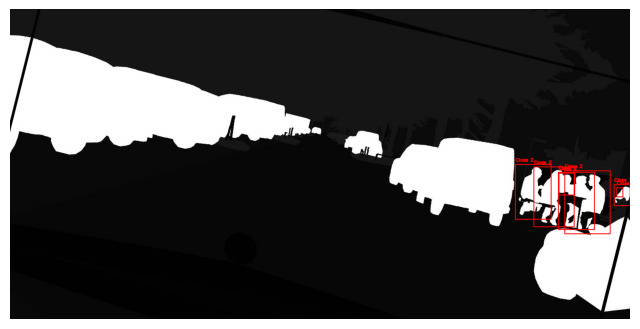

In [ ]:
import matplotlib.pyplot as plt

def visualize_augmentation(image_path, label_path):
    """
    Visualize augmented image with bounding boxes overlayed.

    Args:
        image_path (str): Path to the augmented image.
        label_path (str): Path to the augmented label file.
    """
    # Read the augmented image
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Read the corresponding label file
    with open(label_path, 'r') as f:
        lines = f.readlines()

    # Parse bounding boxes and labels
    for line in lines:
        class_id, x_center, y_center, width, height = map(float, line.strip().split())

        # Convert YOLO format to pixel coordinates
        img_height, img_width, _ = image.shape
        x_min = int((x_center - width / 2) * img_width)
        x_max = int((x_center + width / 2) * img_width)
        y_min = int((y_center - height / 2) * img_height)
        y_max = int((y_center + height / 2) * img_height)

        # Draw the bounding box on the image
        cv2.rectangle(image, (x_min, y_min), (x_max, y_max), color=(255, 0, 0), thickness=2)
        cv2.putText(image, f'Class {int(class_id)}', (x_min, y_min - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)

    # Display the image with bounding boxes
    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# Example usage
aug_image_path = "/kaggle/working/filtered/augmented/images/flip_rotate_left_14_hamburg_000000_098061_gtFinePanopticParts(1).jpg"
aug_label_path = "/kaggle/working/filtered/augmented/labels/flip_rotate_left_14_hamburg_000000_098061_gtFinePanopticParts(1).txt"
visualize_augmentation(aug_image_path, aug_label_path)

This code compares the filenames of images and their corresponding label files in the augmented dataset to ensure they match. It extracts the base names (ignoring file extensions) of the image and label files and checks for any mismatched files. If there are unmatched image files or label files, it reports them, helping to verify that every image has a corresponding label file. If the datasets are aligned correctly, it confirms that all validation images and labels match.









In [ ]:
import os

# Directories for images and labels
val_image_dir = '/kaggle/working/filtered/augmented/images'
val_label_dir = '/kaggle/working/filtered/augmented/labels'

# Get the list of image files and label files
val_images = set(os.listdir(val_image_dir))
val_labels = set(os.listdir(val_label_dir))

# Ensure both lists contain the files with the same base name (ignoring file extensions)
image_base_names = {os.path.splitext(f)[0] for f in val_images if f.endswith('.jpg')}
label_base_names = {os.path.splitext(f)[0] for f in val_labels if f.endswith('.txt')}

# Check if there are any unmatched files
unmatched_images = image_base_names - label_base_names
unmatched_labels = label_base_names - image_base_names

# Print the results
print(f"Number of validation images: {len(val_images)}")
print(f"Number of validation label files: {len(val_labels)}")
print(f"Unmatched image files: {len(unmatched_images)}")
print(f"Unmatched label files: {len(unmatched_labels)}")
print()

# If all is correct, the unmatched sets should be empty
if not unmatched_images and not unmatched_labels:
    print("All validation images and labels match!")
else:
    print("Some validation images and labels do not match.")
    print(f"Unmatched images: {unmatched_images}")
    print(f"Unmatched labels: {unmatched_labels}")
# Define the directories

Number of validation images: 2484
Number of validation label files: 2484
Unmatched image files: 0
Unmatched label files: 0

All validation images and labels match!


This code moves all image files from the source directory (/kaggle/working/filtered/augmented/images) to the destination directory (/kaggle/working/gtFinePanopticParts/train/images). It ensures that the destination directory exists and then moves each file from the source to the destination. After all files are moved, a success message is printed to confirm that the operation was completed.

In [ ]:
import shutil
import os

# Define source and destination directories
source = "/kaggle/working/filtered/augmented/images"
final = "/kaggle/working/gtFinePanopticParts/train/images"

# Ensure the destination directory exists
os.makedirs(final, exist_ok=True)

# Loop through all files in the source directory
for file_name in os.listdir(source):
    source_path = os.path.join(source, file_name)
    final_path = os.path.join(final, file_name)

    # Move the file
    shutil.move(source_path, final_path)

print("Files moved successfully!")

Files moved successfully!


This code moves all label files from the source directory (/kaggle/working/filtered/augmented/labels) to the destination directory (/kaggle/working/gtFinePanopticParts/train/labels). It ensures that the destination directory exists and then moves each file from the source to the destination. After all files are moved, a success message is printed to confirm that the operation was completed.









In [ ]:
import shutil
import os

# Define source and destination directories
source = "/kaggle/working/filtered/augmented/labels"
final = "/kaggle/working/gtFinePanopticParts/train/labels"

# Ensure the destination directory exists
os.makedirs(final, exist_ok=True)

# Loop through all files in the source directory
for file_name in os.listdir(source):
    source_path = os.path.join(source, file_name)
    final_path = os.path.join(final, file_name)

    # Move the file
    shutil.move(source_path, final_path)

print("Files moved successfully!")

Files moved successfully!


This code compares the filenames of images and their corresponding label files in the validation dataset to ensure they match. It checks the base names of the image files and label files (ignoring file extensions), and identifies any mismatches. If there are unmatched image or label files, it reports them. If the datasets are aligned correctly, it confirms that all validation images and labels match, providing an overview of the status.









In [ ]:
import os

# Directories for images and labels
val_image_dir = '/kaggle/working/gtFinePanopticParts/train/images'
val_label_dir = '/kaggle/working/gtFinePanopticParts/train/labels'

# Get the list of image files and label files
val_images = set(os.listdir(val_image_dir))
val_labels = set(os.listdir(val_label_dir))

# Ensure both lists contain the files with the same base name (ignoring file extensions)
image_base_names = {os.path.splitext(f)[0] for f in val_images if f.endswith('.jpg')}
label_base_names = {os.path.splitext(f)[0] for f in val_labels if f.endswith('.txt')}

# Check if there are any unmatched files
unmatched_images = image_base_names - label_base_names
unmatched_labels = label_base_names - image_base_names

# Print the results
print(f"Number of validation images: {len(val_images)}")
print(f"Number of validation label files: {len(val_labels)}")
print(f"Unmatched image files: {len(unmatched_images)}")
print(f"Unmatched label files: {len(unmatched_labels)}")
print()

# If all is correct, the unmatched sets should be empty
if not unmatched_images and not unmatched_labels:
    print("All validation images and labels match!")
else:
    print("Some validation images and labels do not match.")
    print(f"Unmatched images: {unmatched_images}")
    print(f"Unmatched labels: {unmatched_labels}")
# Define the directories

Number of validation images: 5459
Number of validation label files: 5459
Unmatched image files: 0
Unmatched label files: 0

All validation images and labels match!


In [ ]:
import os
from collections import defaultdict

# Define paths and image size
labels_path = "/kaggle/working/gtFinePanopticParts/train/labels"  # Path to your labels folder
image_width = 640  # Width of your images
image_height = 640  # Height of your images
pixel_threshold = 100000000  # Minimum pixel size

# Initialize counters
total_small_objects = 0
class_small_counts = defaultdict(int)  # Stores counts for each class

# Process each label file
for label_file in os.listdir(labels_path):
    if label_file.endswith(".txt"):
        file_path = os.path.join(labels_path, label_file)
        with open(file_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls, x_center, y_center, width, height = map(float, parts)
                # Convert normalized width and height to pixel dimensions
                bbox_width_pixels = width * image_width
                bbox_height_pixels = height * image_height

                # Check if either dimension is smaller than the threshold
                if bbox_width_pixels < pixel_threshold or bbox_height_pixels < pixel_threshold:
                    total_small_objects += 1
                    class_small_counts[int(cls)] += 1  # Increment count for the class

# Output the results
print(f"Total number of  objects  {total_small_objects}")
print("Per-class small object counts:")
for cls, count in class_small_counts.items():
    print(f"Class {cls}: {count}  objects")

Total number of  objects  25804
Per-class small object counts:
Class 1: 2922  objects
Class 3: 3348  objects
Class 0: 16526  objects
Class 2: 3008  objects


The program reads each label file, checks the bounding box information, and stores the filenames that satisfy both conditions in a list. This step begins the process of downsampling the dataset by selecting only the relevant files based on these criteria. It then prints the number of label files that meet these conditions. If desired, the filenames of these files can also be printed for further inspection.









In [ ]:
import os
import random

LABEL_DIR = '/kaggle/working/gtFinePanopticParts/train/labels'  # folder containing .txt files
MAX_WIDTH = 100
MAX_HEIGHT = 100

# List to store filenames that meet the criteria
candidates = []

# Gather all .txt files
label_files = [f for f in os.listdir(LABEL_DIR) if f.endswith('.txt')]

for lbl_file in label_files:
    lbl_path = os.path.join(LABEL_DIR, lbl_file)

    # Track whether this file meets criteria
    all_boxes_class0 = True
    all_boxes_under_size = True
    found_any_box = False

    # Read each line in the .txt file
    with open(lbl_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue  # skip empty lines

            parts = line.split()
            if len(parts) < 5:
                continue  # malformed line, skip

            try:
                class_id = int(parts[0])
                w = float(parts[3])
                h = float(parts[4])
            except ValueError:
                continue  # skip malformed lines

            found_any_box = True

            # Check if class == 0
            if class_id != 0:
                all_boxes_class0 = False
                break  # no need to check further if any box is not class 0

            # Check if width < 0.16 and height < 0.16
            if not (w < MAX_WIDTH and h < MAX_HEIGHT):
                all_boxes_under_size = False
                break  # no need to check further if any box is too large

    # If the file has no boxes at all, decide if that should count or not.
    # For now, we skip empty files from counting.
    if not found_any_box:
        continue

    # The file meets our counting criteria if:
    #   - all boxes are class 0
    #   - all boxes are under the size threshold
    if all_boxes_class0 and all_boxes_under_size:
        candidates.append(lbl_file)

# Print how many files match the criteria
print(f"Found {len(candidates)} label files that have ONLY class=0 and width/height < {MAX_WIDTH}.")

# Optional: print their names if you want to see which ones they are
#print("List of files:")
#for fname in candidates:
#    print(fname)

Found 1082 label files that have ONLY class=0 and width/height < 100.


This code scans the label files in the specified directory and identifies those that contain only class 0 (i.e., no other classes). It reads each label file, extracts the class IDs, and stores the filenames of those that exclusively contain class 0 in a list. This step helps in filtering the dataset for downsampling, focusing only on images with class 0 annotations. Finally, the total count of such label files is printed, giving an overview of how many files meet this condition.









In [ ]:
import os

label_dir = '/kaggle/working/gtFinePanopticParts/train/labels'  # <-- change this to your label folder path

# List to store filenames that have ONLY class 0 (no other classes)
only_0 = []

# Get all .txt files in label_dir
label_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]

for filename in label_files:
    file_path = os.path.join(label_dir, filename)

    # A set to keep track of classes found in this file
    classes_in_file = set()

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue  # skip empty lines

            parts = line.split()
            try:
                class_id = int(parts[0])  # YOLO format: class_id x_center y_center w h
            except ValueError:
                continue  # skip malformed lines

            classes_in_file.add(class_id)

    # Check if the only class present is class 0
    if classes_in_file == {0}:
        only_0.append(filename)

# Print the results
print("Number of label files with ONLY class 0:", len(only_0))

Number of label files with ONLY class 0: 1082


In [ ]:
num_class0_boxes = 0
for fname in only_0:
    file_path = os.path.join(label_dir, fname)
    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue  # skip empty lines
            parts = line.split()
            if len(parts) < 5:
                continue  # skip malformed lines

            class_id = int(parts[0])
            if class_id == 0:
                num_class0_boxes += 1

print(f"Total number of class 0 bounding boxes in 'only_0' files: {num_class0_boxes}")

Total number of class 0 bounding boxes in 'only_0' files: 4633


This code removes the label files and their corresponding images from the dataset where the label files contain only class 0 (i.e., no other classes). It loops through the list of label files identified in the previous step, deletes the label file, and then deletes the associated image file (based on the same base name and possible image extensions such as .jpg, .jpeg, or .png). After deleting the files, it prints the total number of label files and images that were removed, helping to downsample the dataset by excluding unnecessary files.









In [ ]:
import os

# Directories containing labels and images
label_dir = '/kaggle/working/gtFinePanopticParts/train/labels'
image_dir = '/kaggle/working/gtFinePanopticParts/train/images'

# List of label filenames that contain only class 0
# Example: ["image_001.txt", "image_002.txt", ...]


# Possible image extensions (adjust if needed)
possible_exts = ['.jpg', '.jpeg', '.png']

deleted_count = 0

for label_file in only_0:
    # 1) Remove label file
    label_path = os.path.join(label_dir, label_file)
    if os.path.exists(label_path):
        os.remove(label_path)

    # 2) Remove the corresponding image
    #    Usually the image has the same base name (e.g., image_001) but different extension
    base_name, _ = os.path.splitext(label_file)
    for ext in possible_exts:
        img_path = os.path.join(image_dir, base_name + ext)
        if os.path.exists(img_path):
            os.remove(img_path)
            break

    deleted_count += 1

print(f"Deleted {deleted_count} label files and their corresponding images.")

Deleted 1082 label files and their corresponding images.


In this stage, we observe that more downsampling may be needed because class 0 still contains a significant number of objects of different sizes, indicating that further filtering or downsampling may be necessary to balance the dataset and focus on relevant objects.









In [ ]:
import os
from collections import defaultdict

# Define paths and image size
labels_path = "/kaggle/working/gtFinePanopticParts/train/labels"  # Path to your labels folder
image_width = 640  # Width of your images
image_height = 640  # Height of your images
small_pixel_threshold = 10000000
# Minimum pixel size for small objects
large_pixel_threshold = 10000000  # Maximum pixel size for large objects

# Initialize counters
total_small_objects = 0
total_objects = defaultdict(int)  # Stores total counts for each class
small_object_counts = defaultdict(int)  # Stores counts of small objects for each class

# Process each label file
for label_file in os.listdir(labels_path):
    if label_file.endswith(".txt"):
        file_path = os.path.join(labels_path, label_file)
        with open(file_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls, x_center, y_center, width, height = map(float, parts)
                # Convert normalized width and height to pixel dimensions
                bbox_width_pixels = width * image_width
                bbox_height_pixels = height * image_height

                # Update the total object count for this class
                total_objects[int(cls)] += 1

                # Check if the object is smaller than the small threshold
                if bbox_width_pixels < small_pixel_threshold or bbox_height_pixels < small_pixel_threshold:
                    total_small_objects += 1
                    small_object_counts[int(cls)] += 1  # Increment small object count for the class

# Output the results
print(f"Total number of  objects pixels): {total_small_objects}")

for cls, count in small_object_counts.items():
    total_count = total_objects[cls]
    # Calculate the percentage of small objects for this class
    percentage = (count / total_count) * 100 if total_count > 0 else 0
    print(f"Class {cls}: {count}  objects,  ")

Total number of  objects pixels): 21171
Class 1: 2922  objects,  
Class 3: 3348  objects,  
Class 2: 3008  objects,  
Class 0: 11893  objects,  


In this code, we first scan through the label files to identify those that contain more than 10 instances of class 0. The filenames of these label files are stored in the more_than_10_0 list. Then, for these files, we count the occurrences of each class in the dataset. This process helps identify class imbalances or over-represented classes in the files that already contain a significant number of class 0 instances. Finally, the frequency of each class is printed, providing insights into the distribution of object classes in the selected files.

This stage can help in making decisions about further downsampling or balancing the dataset based on class distributions.

In [ ]:
import os
from collections import Counter  # <-- Import Counter

label_dir = '/kaggle/working/gtFinePanopticParts/train/labels'  # <-- change this to your label folder path

# List to store filenames that have more than 10 instances of class 0
more_than_4_0 = []

# Get all .txt files in label_dir
label_files = [f for f in os.listdir(label_dir) if f.endswith('.txt')]

for filename in label_files:
    file_path = os.path.join(label_dir, filename)

    # Counter for occurrences of class 0
    class_0_count = 0

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue  # skip empty lines

            parts = line.split()
            try:
                class_id = int(parts[0])  # YOLO format: class_id x_center y_center w h
            except ValueError:
                continue  # skip malformed lines

            if class_id == 0:
                class_0_count += 1

    if class_0_count > 10:
        more_than_4_0.append(filename)

# Counter to track class frequencies
class_counter = Counter()

# Process only the files in more_than_4_0
for filename in more_than_4_0:
    file_path = os.path.join(label_dir, filename)

    with open(file_path, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue  # skip empty lines

            parts = line.split()
            try:
                class_id = int(parts[0])  # YOLO format: class_id x_center y_center w h
            except ValueError:
                continue  # skip malformed lines

            # Update the counter for the class
            class_counter[class_id] += 1

# Print the class frequencies
print("Class frequencies in the files with more than 10 instances of class 0:")

for class_id, count in class_counter.items():
    print(f"Class {class_id}: {count} occurrences")

Class frequencies in the files with more than 10 instances of class 0:
Class 0: 8173 occurrences
Class 2: 652 occurrences
Class 1: 459 occurrences
Class 3: 738 occurrences


In this code, we remove label files and their corresponding images that contain more than 10 instances of class 0. The process involves first identifying these label files from the more_than_4_0 list and then deleting the corresponding .txt label files and their associated image files (which have the same base name but different extensions like .jpg, .jpeg, or .png). After deleting the files, the code keeps track of how many files were removed and prints the total number of deleted label files and images.

This stage helps further downsample the dataset by eliminating files with a high number of class 0 instances, ensuring a more balanced dataset.

In [ ]:
import os

# Directories containing labels and images
label_dir = '/kaggle/working/gtFinePanopticParts/train/labels'
image_dir = '/kaggle/working/gtFinePanopticParts/train/images'

# List of label filenames that contain only class 0
# Example: ["image_001.txt", "image_002.txt", ...]


# Possible image extensions (adjust if needed)
possible_exts = ['.jpg', '.jpeg', '.png']

deleted_count = 0

for label_file in more_than_4_0:
    # 1) Remove label file
    label_path = os.path.join(label_dir, label_file)
    if os.path.exists(label_path):
        os.remove(label_path)

    # 2) Remove the corresponding image
    #    Usually the image has the same base name (e.g., image_001) but different extension
    base_name, _ = os.path.splitext(label_file)
    for ext in possible_exts:
        img_path = os.path.join(image_dir, base_name + ext)
        if os.path.exists(img_path):
            os.remove(img_path)
            break

    deleted_count += 1

print(f"Deleted {deleted_count} label files and their corresponding images.")

Deleted 374 label files and their corresponding images.


Remove Label Files: For each label file in the list more than 10, the code first checks if the file exists in the label directory. If it does, the label file is deleted.

Remove Corresponding Images: The image file corresponding to the label file is identified by the base name of the label file (without the extension). The code looks for the image in the image_dir directory with potential extensions like .jpg, .jpeg, or .png. If the image is found, it is deleted.

In [ ]:
import os

# Directories containing labels and images
label_dir = '/kaggle/working/gtFinePanopticParts/train/labels'
image_dir = '/kaggle/working/gtFinePanopticParts/train/images'

# List of label filenames that contain only class 0
# Example: ["image_001.txt", "image_002.txt", ...]


# Possible image extensions (adjust if needed)
possible_exts = ['.jpg', '.jpeg', '.png']

deleted_count = 0

for label_file in more_than_4_0:
    # 1) Remove label file
    label_path = os.path.join(label_dir, label_file)
    if os.path.exists(label_path):
        os.remove(label_path)

    # 2) Remove the corresponding image
    #    Usually the image has the same base name (e.g., image_001) but different extension
    base_name, _ = os.path.splitext(label_file)
    for ext in possible_exts:
        img_path = os.path.join(image_dir, base_name + ext)
        if os.path.exists(img_path):
            os.remove(img_path)
            break

    deleted_count += 1

print(f"Deleted {deleted_count} label files and their corresponding images.")

Deleted 374 label files and their corresponding images.


Great! It looks like the dataset has become more balanced, with the object distribution across classes now appearing more even:

Class 0: 3720 objects

Class 1: 2463 objects

Class 2: 2356 objects

Class 3: 2610 objects

This balance will help the model train more effectively, as no single class is dominating the dataset. The downsampling and filtering steps have clearly contributed to a more uniform distribution of classes, which is a key factor in improving the model's performance.

In [ ]:
import os
from collections import defaultdict

# Define paths and image size
labels_path = "/kaggle/working/gtFinePanopticParts/train/labels"  # Path to your labels folder
image_width = 640  # Width of your images
image_height = 640  # Height of your images
small_pixel_threshold = 10000000  # Minimum pixel size for small objects
large_pixel_threshold =1000000  # Maximum pixel size for large objects

# Initialize counters
total_small_objects = 0
total_objects = defaultdict(int)  # Stores total counts for each class
small_object_counts = defaultdict(int)  # Stores counts of small objects for each class

# Process each label file
for label_file in os.listdir(labels_path):
    if label_file.endswith(".txt"):
        file_path = os.path.join(labels_path, label_file)
        with open(file_path, 'r') as f:
            lines = f.readlines()

        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 5:
                cls, x_center, y_center, width, height = map(float, parts)
                # Convert normalized width and height to pixel dimensions
                bbox_width_pixels = width * image_width
                bbox_height_pixels = height * image_height

                # Update the total object count for this class
                total_objects[int(cls)] += 1

                # Check if the object is smaller than the small threshold
                if bbox_width_pixels < small_pixel_threshold or bbox_height_pixels < small_pixel_threshold:
                    total_small_objects += 1
                    small_object_counts[int(cls)] += 1  # Increment small object count for the class

# Output the results
print(f"Total number of  objects : {total_small_objects}")

for cls, count in small_object_counts.items():
    total_count = total_objects[cls]
    # Calculate the percentage of small objects for this class
    percentage = (count / total_count) * 100 if total_count > 0 else 0
    print(f"Class {cls}: {count}  objects,")

Total number of  objects : 11149
Class 1: 2463  objects,
Class 3: 2610  objects,
Class 2: 2356  objects,
Class 0: 3720  objects,


This code creates a YAML configuration file for a custom YOLO dataset, which includes paths to the training and validation images, the number of classes, class names, and class weights. The class_weights dictionary is used to assign higher importance to certain classes, making the model focus more on underrepresented classes during training. In this case, class 0 has a weight of 1.0, while classes 1, 2, and 3 are assigned a higher weight of 5.0 to handle class imbalance.

The YAML configuration is saved as my_dataset1.yaml, which can be used for training a custom YOLOv5 or YOLOv8 model. This configuration file ensures that the model is aware of the dataset's structure and the class balancing requirements

In [ ]:
import yaml

# Paths to your dataset folders
train_images_path = '/kaggle/working/gtFinePanopticParts/train'
val_images_path = '/kaggle/working/gtFinePanopticParts/val'

# Define class weights for imbalanced data
# Higher values mean the model will pay more attention to these classes
class_weights = {0: 1.0, 1: 30.0, 2: 5.0, 3: 5.0}  # Adjust as necessary <button class="citation-flag" data-index="3">

# YOLOv5/YOLOv8 configuration for custom dataset with class weights
data_config = {
    'train': train_images_path,
    'val': val_images_path,
    'nc': 4,  # Number of classes
    'names': ["pedestrian", "rider", "sitting person", "person group"],
    'class_weights': class_weights  # Add class weights to the config
}

# Save the YAML file
with open('my_dataset1.yaml', 'w') as file:
    yaml.dump(data_config, file)

print("YAML configuration file created as my_dataset1.yaml")

YAML configuration file created as my_dataset1.yaml


In [ ]:
# Clone YOLOv5 repository
!git clone https://github.com/ultralytics/yolov5
%cd yolov5

# Install the dependencies
!pip install -r requirements.txt

Cloning into 'yolov5'...
remote: Enumerating objects: 17270, done.
remote: Counting objects: 100% (1/1), done.
remote: Total 17270 (delta 0), reused 0 (delta 0), pack-reused 17269 (from 2)
Receiving objects: 100% (17270/17270), 16.12 MiB | 30.96 MiB/s, done.
Resolving deltas: 100% (11858/11858), done.
/kaggle/working/yolov5
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 922.1/922.1 kB 23.7 MB/s eta 0:00:0000:01


In [ ]:
!python /kaggle/working/yolov5/train.py \
    --img 1280 \
    --batch-size 16 \
    --epochs 10 \
    --data /kaggle/working/my_dataset1.yaml \
    --weights yolov5m6.pt \
    --cache

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2025-03-01 11:30:24.500458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-01 11:30:24.759684: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-01 11:30:24.840808: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to regi

Text(45.72222222222221, 0.5, 'True Label')

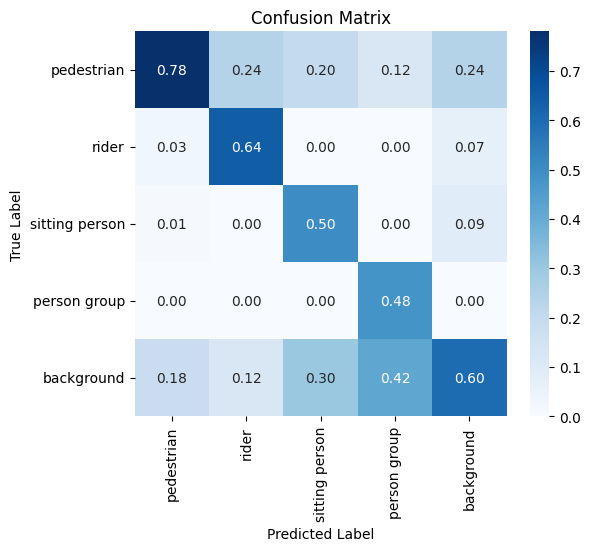

In [ ]:


# 5. Display the plot
plt.show()
from IPython.display import Image, display
display(Image(filename='/kaggle/working/yolov5/runs/val/exp6/confusion_matrix.png', width=800))


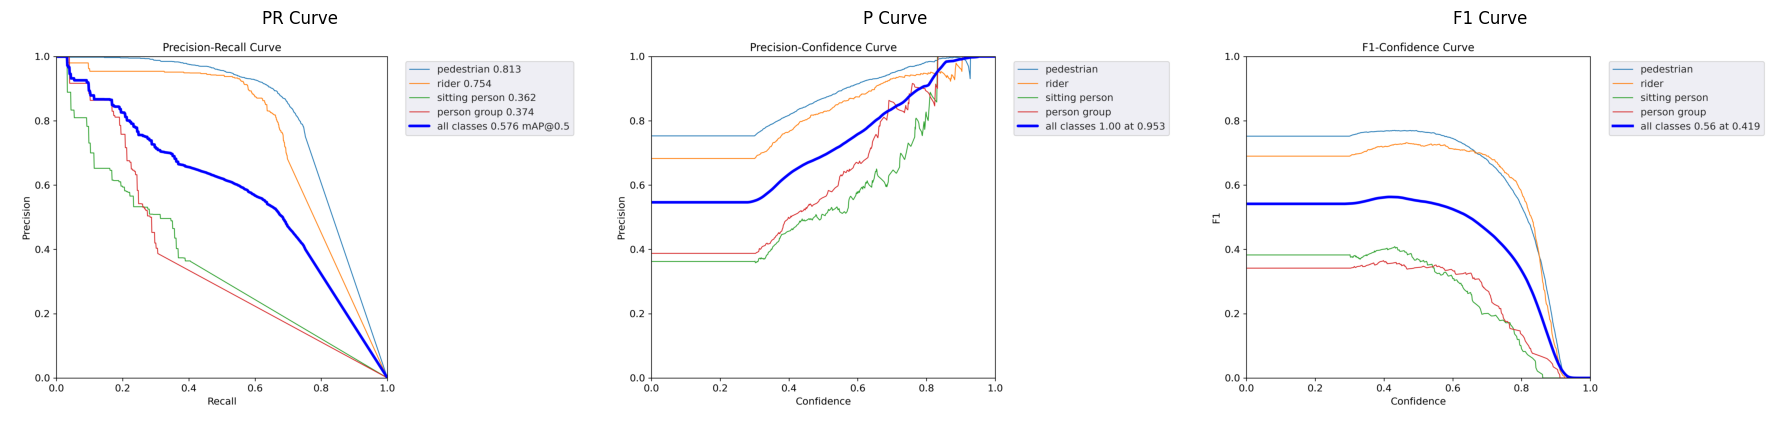

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load image
img_pr = mpimg.imread('/kaggle/working/yolov5/runs/val/exp/PR_curve.png')
img_p  = mpimg.imread('/kaggle/working/yolov5/runs/val/exp/P_curve.png')
img_f1 = mpimg.imread('/kaggle/working/yolov5/runs/val/exp/F1_curve.png')

# Create a figure with 1 row and 3 columns
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Display the PR curve
axs[0].imshow(img_pr)
axs[0].axis('off')
axs[0].set_title("PR Curve")

# Display the P curve
axs[1].imshow(img_p)
axs[1].axis('off')
axs[1].set_title("P Curve")

# Display the F1 curve
axs[2].imshow(img_f1)
axs[2].axis('off')
axs[2].set_title("F1 Curve")

plt.tight_layout()
plt.show()


In [ ]:
!python detect.py --weights /kaggle/working/yolov5/runs/train/exp/weights/best.pt --source /kaggle/working/filtered/images/ --conf 0.5 --iou 0.45  --save-txt --save-conf


detect: weights=['/kaggle/working/yolov5/runs/train/exp/weights/best.pt'], source=/kaggle/working/filtered/images/, data=data/coco128.yaml, imgsz=[640, 640], conf_thres=0.5, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-398-g5cdad892 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 276 layers, 35266236 parameters, 0 gradients, 48.9 GFLOPs
image 1/36 /kaggle/working/filtered/images/aachen_000000_000019_gtFinePanopticParts.jpg: 320x640 1 rider, 2 sitting persons, 46.1ms
image 2/36 /kaggle/working/filtered/images/aachen_000166_000019_gtFinePanopticParts.jpg: 320x640 1 sitting person, 20.0ms
image 3/36 /kaggle/working

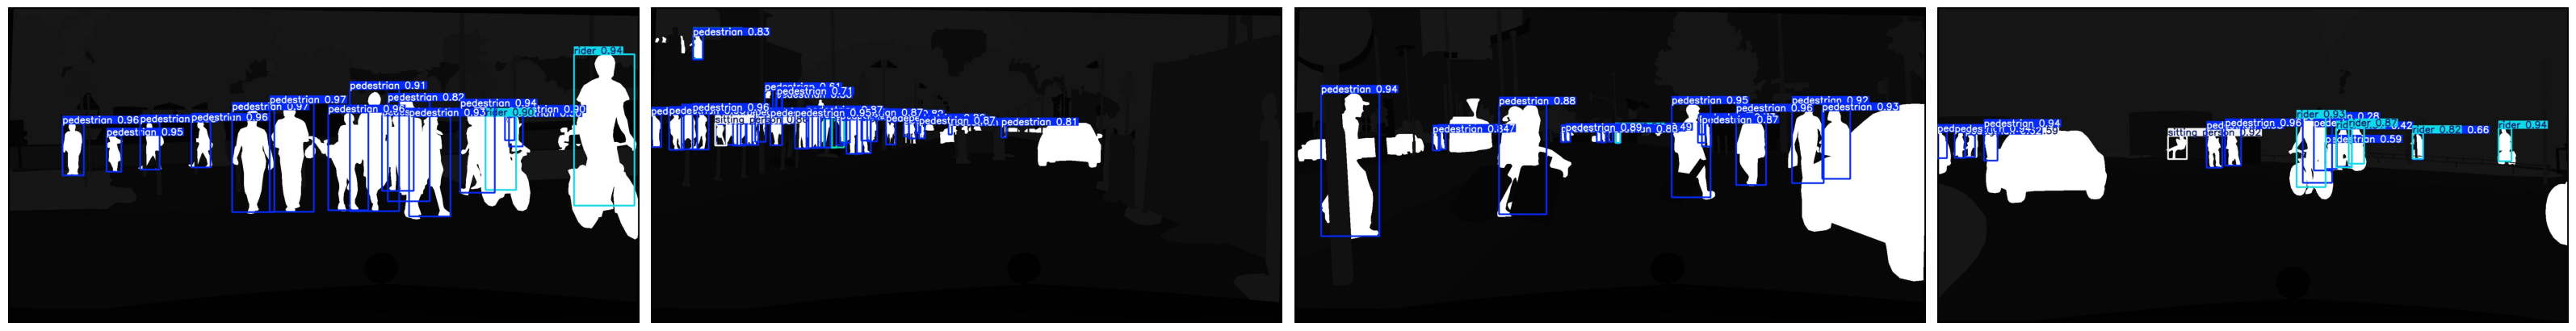

In [ ]:
import math
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# List of image paths
image_paths = [
    '/kaggle/working/yolov5/runs/detect/exp15/cologne_000118_000019_gtFinePanopticParts.jpg',
    '/kaggle/working/yolov5/runs/detect/exp15/dusseldorf_000025_000019_gtFinePanopticParts.jpg',
    '/kaggle/working/yolov5/runs/detect/exp15/dusseldorf_000025_000019_gtFinePanopticParts.jpg',
    '/kaggle/working/yolov5/runs/detect/exp15/erfurt_000042_000019_gtFinePanopticParts.jpg',


# Define grid dimensions: here we use 3 columns
cols = 3
rows = math.ceil(len(image_paths) / cols)

# Increase the overall figure size; adjust the multipliers to get larger images
fig, axs = plt.subplots(rows, cols, figsize=(cols * 6, rows * 5))
axs = axs.flatten()

for i, ax in enumerate(axs):
    if i < len(image_paths):
        img = mpimg.imread(image_paths[i])
        ax.imshow(img)
        ax.set_title(image_paths[i].split('/')[-1], fontsize=10)
        ax.axis('off')
    else:
        ax.axis('off')  # Hide any extra subplots

plt.tight_layout()
plt.show()


In [ ]:

!python /kaggle/working/yolov5/val.py \
    --weights /kaggle/working/yolov5/runs/train/exp/weights/best.pt \
    --data /kaggle/working/my_dataset1.yaml \
    --img 1280 \
    --batch-size 64 \
    --conf-thres 0.3 \
    --iou-thres .5 \
    --task val \
    --save-json

val: data=/kaggle/working/my_dataset1.yaml, weights=['/kaggle/working/yolov5/runs/train/exp/weights/best.pt'], batch_size=64, imgsz=1280, conf_thres=0.3, iou_thres=0.5, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=True, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
WARNING ⚠️ confidence threshold 0.3 > 0.001 produces invalid results
YOLOv5 🚀 v7.0-398-g5cdad892 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 276 layers, 35266236 parameters, 0 gradients, 48.9 GFLOPs
val: Scanning /kaggle/working/gtFinePanopticParts/val/labels.cache... 500 images
                 Class     Images  Instances          P          R      mAP50   
                   all        500       4077      0.646      0.504      0.576      0.375
            pedestrian        500       3157      0.827      0.717      0.813      0.556
                

In [ ]:

!python /kaggle/working/yolov5/val.py \
    --weights /kaggle/working/yolov5/runs/train/exp/weights/best.pt \
    --data /kaggle/working/my_dataset1.yaml \
    --img 1280 \
    --batch-size 64 \
    --conf-thres 0.5 \
    --iou-thres .5 \
    --task val \
    --save-json

val: data=/kaggle/working/my_dataset1.yaml, weights=['/kaggle/working/yolov5/runs/train/exp/weights/best.pt'], batch_size=64, imgsz=1280, conf_thres=0.5, iou_thres=0.5, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=True, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
WARNING ⚠️ confidence threshold 0.5 > 0.001 produces invalid results
YOLOv5 🚀 v7.0-398-g5cdad892 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 276 layers, 35266236 parameters, 0 gradients, 48.9 GFLOPs
val: Scanning /kaggle/working/gtFinePanopticParts/val/labels.cache... 500 images
                 Class     Images  Instances          P          R      mAP50   
                   all        500       4077      0.692      0.467      0.591      0.397
            pedestrian        500       3157       0.87      0.686      0.802      0.566
                

In [ ]:

!python /kaggle/working/yolov5/val.py \
    --weights /kaggle/working/yolov5/runs/train/exp/weights/best.pt \
    --data /kaggle/working/my_dataset1.yaml \
    --img 1280 \
    --batch-size 64 \
    --conf-thres 0.3 \
    --iou-thres .6 \
    --task val \
    --save-json

val: data=/kaggle/working/my_dataset1.yaml, weights=['/kaggle/working/yolov5/runs/train/exp/weights/best.pt'], batch_size=64, imgsz=1280, conf_thres=0.3, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=True, project=runs/val, name=exp, exist_ok=False, half=False, dnn=False
WARNING ⚠️ confidence threshold 0.3 > 0.001 produces invalid results
YOLOv5 🚀 v7.0-398-g5cdad892 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (Tesla T4, 15095MiB)

Fusing layers... 
Model summary: 276 layers, 35266236 parameters, 0 gradients, 48.9 GFLOPs
val: Scanning /kaggle/working/gtFinePanopticParts/val/labels.cache... 500 images
                 Class     Images  Instances          P          R      mAP50   
                   all        500       4077      0.631      0.503      0.568       0.37
            pedestrian        500       3157      0.772      0.723      0.803      0.546
                

/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)
/usr/local/lib/python3.10/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


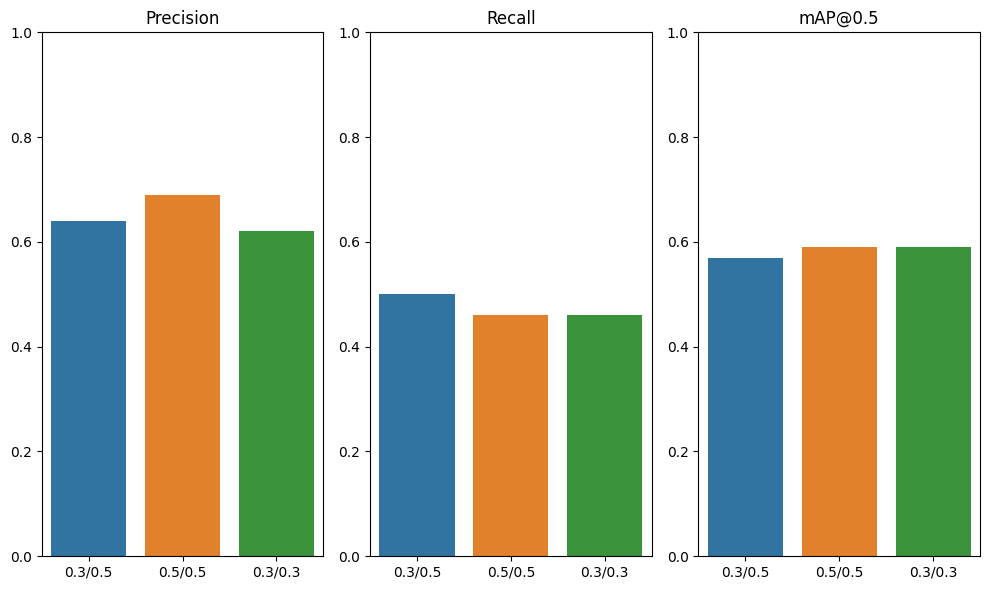

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Data
conf_thres = [0.3, 0.5, 0.3]
iou_thres = [0.5, 0.5, 0.3]
precision = [0.64, 0.69, 0.62]
recall = [0.50, 0.46, 0.46]
mAP = [0.57, 0.591, 0.59]

# Plot Precision, Recall, and mAP
plt.figure(figsize=(10, 6))

plt.subplot(1, 3, 1)
sns.barplot(x=['0.3/0.5', '0.5/0.5', '0.3/0.3'], y=precision)
plt.title('Precision')
plt.ylim(0, 1)

plt.subplot(1, 3, 2)
sns.barplot(x=['0.3/0.5', '0.5/0.5', '0.3/0.3'], y=recall)
plt.title('Recall')
plt.ylim(0, 1)

plt.subplot(1, 3, 3)
sns.barplot(x=['0.3/0.5', '0.5/0.5', '0.3/0.3'], y=mAP)
plt.title('mAP@0.5')
plt.ylim(0, 1)

plt.tight_layout()
plt.show()